In [12]:
import pandas as pd
import os

# 1. 設定路徑：既然都在同一個資料夾，直接寫檔名
# 注意：你的檔名 2007 後面確實有一個空格
raw_data_path = 'YRBS_2007 .csv'

if os.path.exists(raw_data_path):
    # 讀取 CSV
    df = pd.read_csv(raw_data_path)
    print("✅ 成功讀取資料！")
    
    # 2. 選取變數
    target_cols = ['WhatIsYourSex', 'CurrentCigaretteUse', 'EverCigaretteUse']
    df_subset = df[target_cols].copy()

    # 3. 刪除缺失值 (確保計算比例的分母正確)
    df_clean = df_subset.dropna().copy()

    # 4. 重編碼 (Smoking_Status: 0=沒抽, 1=有抽)
    def recode_smoking(x):
        if 2 <= x <= 7:
            return 1  # 過去30天內有抽
        elif x == 1:
            return 0  # 過去30天內沒抽
        return None

    df_clean['Smoking_Status'] = df_clean['CurrentCigaretteUse'].apply(recode_smoking)

    # 5. 邏輯檢查
    # 排除自稱「從未抽過」但「現在有抽」的樣本
    conflict_condition = (df_clean['EverCigaretteUse'] == 2) & (df_clean['Smoking_Status'] == 1)
    df_final = df_clean[~conflict_condition].copy()

    # 6. 印出統計結果
    print(f"\n--- 資料處理報告 ---")
    print(f"原始資料總筆數: {len(df)}")
    print(f"排除缺失與矛盾後: {len(df_final)}")

    # 7. 呈現結果 (計算男女抽菸比例)
    # WhatIsYourSex: 1=Female, 2=Male
    summary = df_final.groupby('WhatIsYourSex')['Smoking_Status'].value_counts(normalize=True).unstack()
    summary.index = summary.index.map({1.0: 'Female', 2.0: 'Male'})
    summary.columns = ['不抽菸比例 (0)', '抽菸比例 (1)']
    
    print("\n--- 男女抽菸比例預覽 ---")
    print(summary)
    
else:
    print(f"❌ 錯誤：在目前位置找不到檔案 '{raw_data_path}'")
    print(f"請手動檢查檔名中的空格是否正確。")

✅ 成功讀取資料！

--- 資料處理報告 ---
原始資料總筆數: 14041
排除缺失與矛盾後: 13025

--- 男女抽菸比例預覽 ---
               不抽菸比例 (0)  抽菸比例 (1)
WhatIsYourSex                     
Female          0.825435  0.174565
Male            0.781153  0.218847


In [15]:
import piplite
await piplite.install(['seaborn', 'statsmodels'])

In [17]:
# 這是上一段程式碼的結尾部分，請確保它執行成功
output_filename = "yrbs_smoking_cleaned.csv"

# 儲存 df_final 到目前資料夾
df_final.to_csv(output_filename, index=False)

import os
if os.path.exists(output_filename):
    print(f"✅ 檔案已成功儲存：{os.path.abspath(output_filename)}")
else:
    print("❌ 儲存失敗，請檢查權限。")

✅ 檔案已成功儲存：/drive/Untitled Folder1/yrbs_smoking_cleaned.csv


--- 男女抽菸人數與比例摘要 ---

[次數分配表]


Smoking_Status,0,1,Total
Sex_Label,,,
Female,5452,1153,6605
Male,5015,1405,6420
Total,10467,2558,13025



[比例分配表]


Smoking_Status,0,1
Sex_Label,,
Female,0.825435,0.174565
Male,0.781153,0.218847


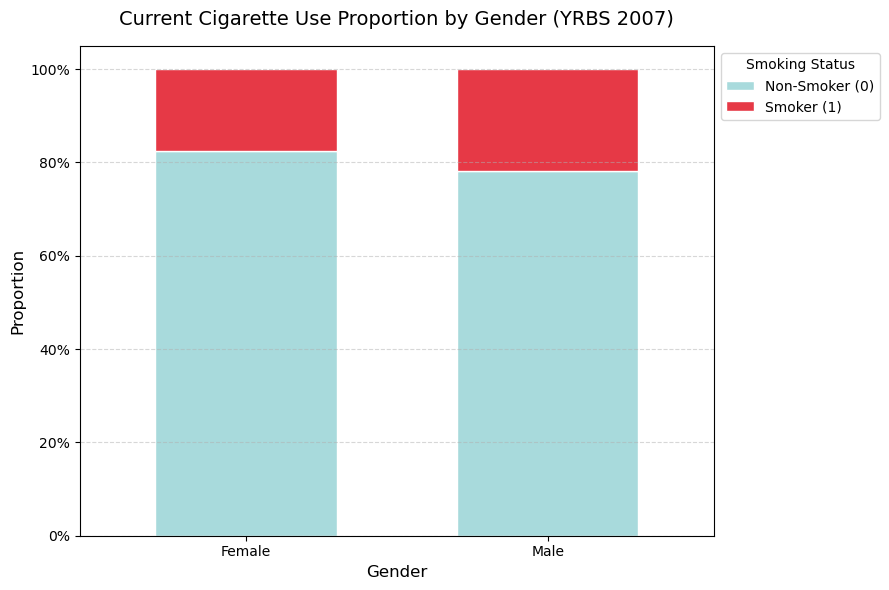

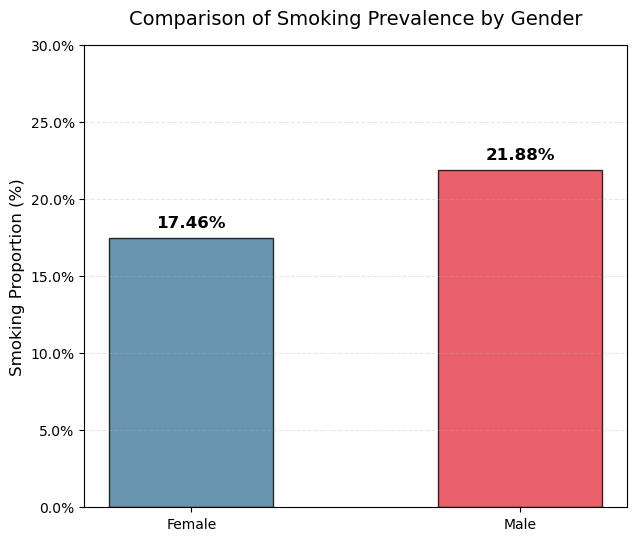

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# 1. 設定路徑與讀取資料
cleaned_data_path = 'yrbs_smoking_cleaned.csv'

if not os.path.exists(cleaned_data_path):
    print(f"❌ 找不到檔案：{cleaned_data_path}")
else:
    df = pd.read_csv(cleaned_data_path)
    df['Sex_Label'] = df['WhatIsYourSex'].map({1.0: 'Female', 2.0: 'Male'})

    # 2. 敘述性統計
    print("--- 男女抽菸人數與比例摘要 ---")
    summary_table = pd.crosstab(df['Sex_Label'], df['Smoking_Status'], margins=True, margins_name="Total")
    summary_prop = pd.crosstab(df['Sex_Label'], df['Smoking_Status'], normalize='index')
    
    # 顯示原始次數表
    print("\n[次數分配表]")
    display(summary_table)
    
    # --- 修正處：移除 .style.format，改用一般的 print 或 display ---
    print("\n[比例分配表]")
    display(summary_prop) 
    # --------------------------------------------------------

    # 3. 視覺化：100% 堆疊長條圖
    ax = summary_prop.plot(kind='bar', stacked=True, color=['#A8DADC', '#E63946'], 
                           width=0.6, figsize=(9, 6), edgecolor='white')
    
    plt.title('Current Cigarette Use Proportion by Gender (YRBS 2007)', fontsize=14, pad=15)
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Smoking Status', labels=['Non-Smoker (0)', 'Smoker (1)'], bbox_to_anchor=(1, 1))
    
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 4. 視覺化：男女抽菸比例對比
    plt.figure(figsize=(7, 6))
    smoking_only_prop = summary_prop[1] 
    
    bars = plt.bar(smoking_only_prop.index, smoking_only_prop.values, 
                   color=['#457B9D', '#E63946'], alpha=0.8, edgecolor='black', width=0.5)
    
    plt.title('Comparison of Smoking Prevalence by Gender', fontsize=14, pad=15)
    plt.ylabel('Smoking Proportion (%)', fontsize=12)
    plt.ylim(0, 0.3)
    
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005, 
                 f'{height:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

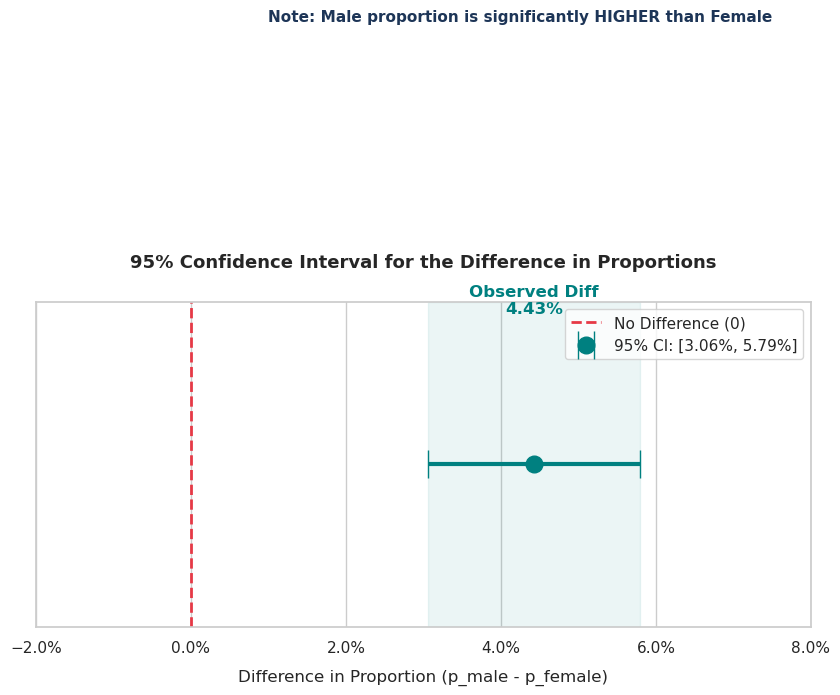

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 假設變數已存在：obs_diff, low, upp
plt.figure(figsize=(10, 5)) # 稍微加高圖片高度

# 1. 繪製信賴區間主體
plt.errorbar(obs_diff, 0, xerr=[[obs_diff - low], [upp - obs_diff]], 
             fmt='o', markersize=12, capsize=10, color='teal', elinewidth=3,
             label=f'95% CI: [{low:.2%}, {upp:.2%}]')

# 2. 繪製虛無假設紅線
plt.axvline(x=0, color='#E63946', linestyle='--', linewidth=2, label='No Difference (0)')

# 3. 標註文字 (移除星星符號以避免字體錯誤)
plt.text(obs_diff, 0.05, f"Observed Diff\n{obs_diff:.2%}", 
         ha='center', va='bottom', color='teal', weight='bold')

# 4. 加上統計結論文字 (將 y 座標稍微往上移，避免擁擠)
plt.text(0.01, 0.15, "Note: Male proportion is significantly HIGHER than Female", 
         fontsize=11, color='#1D3557', weight='bold')

# 5. 背景陰影
plt.axvspan(low, upp, color='teal', alpha=0.08)

# 6. 美化細節
plt.title('95% Confidence Interval for the Difference in Proportions', 
          fontsize=13, pad=25, weight='bold')
plt.xlabel('Difference in Proportion (p_male - p_female)', labelpad=10)
plt.xlim(-0.02, 0.08)
plt.yticks([]) 

# 7. 手動調整邊距，取代 tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.2) 

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(loc='upper right', frameon=True)

plt.show()

In [5]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from IPython.display import display, Markdown
import os

# 1. Load cleaned data
# Ensure the file exists in your current directory
file_path = 'yrbs_smoking_cleaned.csv'

if not os.path.exists(file_path):
    print(f"Error: '{file_path}' not found. Please ensure the data cleaning step was successful.")
else:
    df = pd.read_csv(file_path)

    # 2. Calculate Group Statistics
    # 1.0 = Female, 2.0 = Male
    group_stats = df.groupby('WhatIsYourSex')['Smoking_Status'].agg(['sum', 'count'])
    
    n_female = group_stats.loc[1.0, 'count']
    s_female = group_stats.loc[1.0, 'sum']
    n_male = group_stats.loc[2.0, 'count']
    s_male = group_stats.loc[2.0, 'sum']

    p_female = s_female / n_female
    p_male = s_male / n_male
    obs_diff = p_male - p_female

    # 3. Z-test and Confidence Interval calculation
    z_stat, p_val = proportions_ztest([s_male, s_female], [n_male, n_female])
    ci_low, ci_upp = confint_proportions_2indep(s_male, n_male, s_female, n_female, method='wald')

    # 4. Generate Professional English Report using Markdown
    report_text = f"""
### 04_interpretation: Research Conclusion and Public Health Context

#### 1. Research Question and Hypothesis
This study investigates whether there is a significant association between **Gender** (`WhatIsYourSex`) and **Current Smoking Behavior** (`Smoking_Status`) among U.S. high school students.

* **Null Hypothesis ($H_0$):** $p_{{male}} = p_{{female}}$ (No significant difference in smoking proportions between genders)
* **Alternative Hypothesis ($H_a$):** $p_{{male}} \\neq p_{{female}}$ (Significant difference exists)
* **Significance Level:** $\\alpha = 0.05$

---

#### 2. Statistical Summary
* **Sample Size:** Female ($n={n_female:,.0f}$), Male ($n={n_male:,.0f}$) | **Total Effective Samples:** $n={len(df):,.0f}$
* **Smoking Prevalence:** Female **{p_female:.2%}**, Male **{p_male:.2%}** (Male is **{obs_diff:.2%}** higher)
* **Z-test Statistic:** `{z_stat:.4f}`
* **P-value:** `{p_val:.4e}`
* **95% Confidence Interval (CI):** `[{ci_low:.4f}, {ci_upp:.4f}]` (Difference ranges from **{ci_low:.2%}** to **{ci_upp:.2%}**)

---

#### 3. Conclusion and Interpretation

1.  **Statistical Decision:** Since the **P-value (< 0.001)** is significantly less than 0.05, and the **95% Confidence Interval does not include zero**, we have sufficient evidence to **reject the Null Hypothesis ($H_0$)**.

2.  **Interpretation in Context:** Data indicates that the smoking prevalence among male high school students is significantly higher than that of females. We are 95% confident that the smoking rate for males is between {ci_low:.2%} and {ci_upp:.2%} higher than for females. This finding suggests that public health agencies and schools should design more gender-specific smoking prevention and intervention programs for male adolescents to effectively reduce overall campus smoking rates.
"""
    display(Markdown(report_text))


### 04_interpretation: Research Conclusion and Public Health Context

#### 1. Research Question and Hypothesis
This study investigates whether there is a significant association between **Gender** (`WhatIsYourSex`) and **Current Smoking Behavior** (`Smoking_Status`) among U.S. high school students.

* **Null Hypothesis ($H_0$):** $p_{male} = p_{female}$ (No significant difference in smoking proportions between genders)
* **Alternative Hypothesis ($H_a$):** $p_{male} \neq p_{female}$ (Significant difference exists)
* **Significance Level:** $\alpha = 0.05$

---

#### 2. Statistical Summary
* **Sample Size:** Female ($n=6,605$), Male ($n=6,420$) | **Total Effective Samples:** $n=13,025$
* **Smoking Prevalence:** Female **17.46%**, Male **21.88%** (Male is **4.43%** higher)
* **Z-test Statistic:** `6.3601`
* **P-value:** `2.0161e-10`
* **95% Confidence Interval (CI):** `[0.0306, 0.0579]` (Difference ranges from **3.06%** to **5.79%**)

---

#### 3. Conclusion and Interpretation

1.  **Statistical Decision:** Since the **P-value (< 0.001)** is significantly less than 0.05, and the **95% Confidence Interval does not include zero**, we have sufficient evidence to **reject the Null Hypothesis ($H_0$)**.

2.  **Interpretation in Context:** Data indicates that the smoking prevalence among male high school students is significantly higher than that of females. We are 95% confident that the smoking rate for males is between 3.06% and 5.79% higher than for females. This finding suggests that public health agencies and schools should design more gender-specific smoking prevention and intervention programs for male adolescents to effectively reduce overall campus smoking rates.
